# Land Cover Classification Framework

The workflow will cover how to retrieve LandSat Imagery and create a landcover classifier. We will use the landcover classifier to examine changes over time.

## Case Application: Great Salt Lake

The Great Salt Lake (GSL) fluctuates both from natural seasonality, year-to-year climate anomolies, and anthropogentic water use (e.g., diversions, growth, development). In today's example, we will retrieve LandSat imagery and develop a land cover classifier to examine the changes in area of the GSL over time.

In [ ]:
from utils import getLandSat
import ee
import rasterio
import matplotlib.pyplot as plt

/home/whitelightning450/mambaforge/envs/hyriver/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [143]:
importlib.reload(getLandSat)

<module 'utils.getLandSat' from '/home/whitelightning450/HydroInformatics/Intro-to-MachineLearning/utils/getLandSat.py'>

### LandSat Data Retrievel

Use the data retrievel functions to collect LandSat Imagery of the GSL

In [144]:
# Define the bounding box for the region of interest (ROI)
xmin = -113.2
xmax = -111.95
ymin = 40.5
ymax = 41.85

# # Get the ROI as a GeoJSON object
roi = getLandSat.get_bbox([xmin, ymin, xmax, ymax])

#call the getLandSat function to download the data for the specified ROI and time range
getLandSat.export_monthly_range_parallel(
    roi=roi,
    output_dir="data/LandSat/GSL",
    start_year=2025,
    end_year=2025,
    max_workers=3,
    months_before=2,
    months_after=2,
    reducer="median"
)

Prepared 12 monthly jobs
Generating URL ...
Generating URL ...
Generating URL ...
Please wait ...
Please wait ...
Please wait ...
Data downloaded to /home/whitelightning450/HydroInformatics/Intro-to-MachineLearning/data/LandSat/GSL/GSL_2025_01.tif
Saved to data/LandSat/GSL/GSL_2025_01.tif
Finished: data/LandSat/GSL/GSL_2025_01.tif
Generating URL ...
Data downloaded to /home/whitelightning450/HydroInformatics/Intro-to-MachineLearning/data/LandSat/GSL/GSL_2025_02.tif
Saved to data/LandSat/GSL/GSL_2025_02.tif
Finished: data/LandSat/GSL/GSL_2025_02.tif
Generating URL ...
Data downloaded to /home/whitelightning450/HydroInformatics/Intro-to-MachineLearning/data/LandSat/GSL/GSL_2025_03.tif
Saved to data/LandSat/GSL/GSL_2025_03.tif
Finished: data/LandSat/GSL/GSL_2025_03.tif
Generating URL ...
Please wait ...
Please wait ...
Please wait ...
Data downloaded to /home/whitelightning450/HydroInformatics/Intro-to-MachineLearning/data/LandSat/GSL/GSL_2025_05.tif
Saved to data/LandSat/GSL/GSL_2025_05.

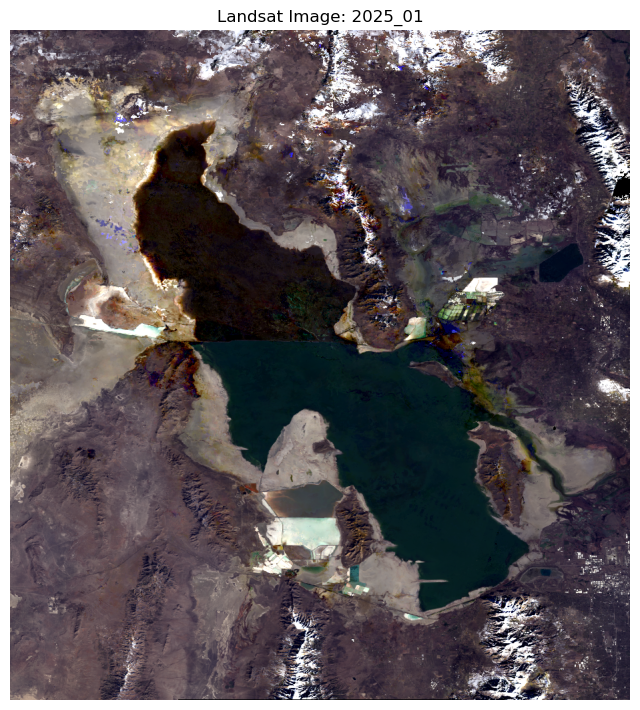

In [146]:

Path = 'data/LandSat/GSL/'
date = '2025_01'
filepath = f"{Path}GSL_{date}.tif"

with rasterio.open(filepath) as src:
    img = src.read()  # (bands, rows, cols)

# Convert to (rows, cols, bands)
img = img.transpose(1, 2, 0)

# Normalize for display (important!)
img = img / img.max()

plt.figure(figsize=(8,89))
plt.imshow(img)
plt.title(f"Landsat Image: {date}")
plt.axis("off")
plt.show()